In [1]:
# verify if the environment (ts-classification-env) is correct and node is as expected (scotia or hermann)
import sys
print(sys.executable)

import socket
print(socket.gethostname())

/home/pborole/anaconda3/envs/timesfm_py311/bin/python3.11
scotia06.inf.ed.ac.uk


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn.metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
from sklearn.metrics import (
    auc,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve
)

# TimesFM

task: cip 
accuracy: 0.7245762711864406 
precision: 0.7604790419161677  
recall: 0.8355263157894737  
f1: 0.7962382445141066  
auroc: 0.7657424812030076  
auprc: 0.8517070343742204 

task: tet 
accuracy: 0.72 
precision: 0.75  
recall: 0.8297872340425532  
f1: 0.7878787878787878  
auroc: 0.7933975008443093  
auprc: 0.866877396938593 

task: ciptet 
accuracy: 0.7511111111111111 
precision: 0.7777777777777778  
recall: 0.8439716312056738  
f1: 0.8095238095238095  
auroc: 0.7926376224248565  
auprc: 0.8461622816391823 



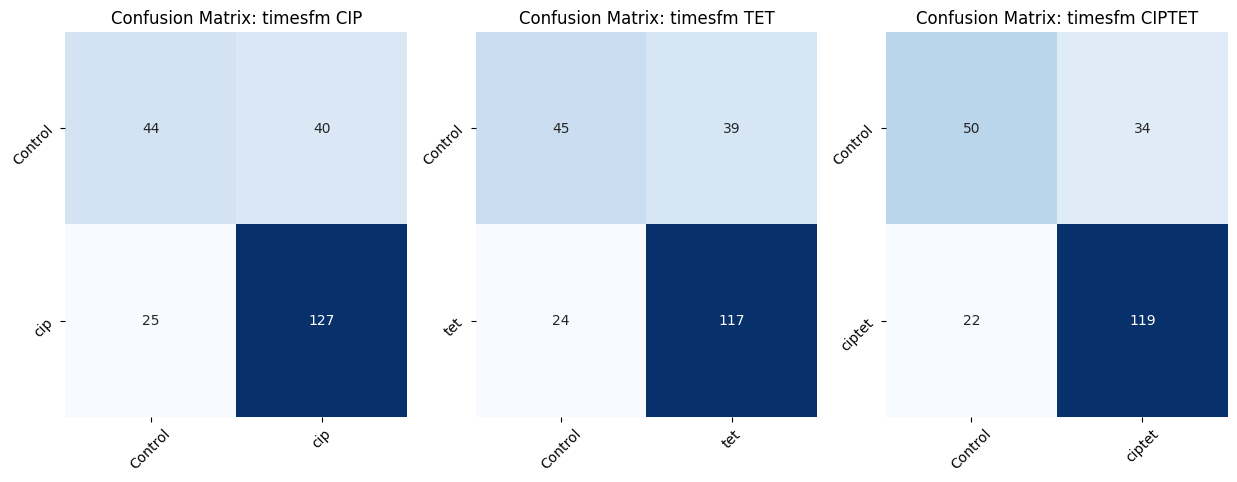

In [3]:
ename = 'timesfm'
tasks = ['cip', 'tet', 'ciptet']
fig, ax = plt.subplots(1, 3, figsize=(15,5))

for idx, task in enumerate(tasks):
    result_df = pd.read_csv(f'./results/predictions/final_test_predictions_tsclassifier_{ename}_{task}.csv')
    y_true = result_df['y_true'].to_list()
    y_pred = result_df['y_pred'].to_list()
    y_probs = result_df['y_probs'].to_list()

    confusion_matrix = sklearn.metrics.confusion_matrix(y_true, y_pred)
    # confusion_matrix = confusion_matrix/np.sum(confusion_matrix)*100
    b = sns.heatmap(
        confusion_matrix, 
        annot=True, 
        xticklabels=False, 
        yticklabels=False, 
        cbar=False, 
        cmap="Blues",
        fmt='g',
        ax=ax[idx]
    )
    b.set_title(f'Confusion Matrix: {ename} {task.upper()}')
    b.set_xticks([0.5,1.5],['Control',task],rotation=45)
    b.set_yticks([0.5,1.5],['Control',task],rotation=45)


    # Accurcy
    accuracy = accuracy_score(y_pred=y_pred, y_true=y_true)
    # AUROC
    auroc = roc_auc_score(y_true, y_probs)
    # AUPRC
    precision, recall, _ = precision_recall_curve(y_true, y_probs)
    auprc = auc(recall, precision)
    # Precision
    precision = precision_score(y_true, y_pred, zero_division=0)
    # Recall
    recall = recall_score(y_true, y_pred, zero_division=0)
    # f1
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(
        f"task: {task} \n"
        f"accuracy: {accuracy} \n"
        f"precision: {precision}  \n"
        f"recall: {recall}  \n"
        f"f1: {f1}  \n"
        f"auroc: {auroc}  \n"
        f"auprc: {auprc} \n"
    )

# MOMENT 1 BASE

task: cip 
accuracy: 0.8050847457627118 
precision: 0.8397435897435898  
recall: 0.8618421052631579  
f1: 0.8506493506493507  
auroc: 0.8460213032581453  
auprc: 0.8726563850779196 

task: tet 
accuracy: 0.8488888888888889 
precision: 0.9421487603305785  
recall: 0.8085106382978723  
f1: 0.8702290076335878  
auroc: 0.9201705504896994  
auprc: 0.9465509351371676 

task: ciptet 
accuracy: 0.8488888888888889 
precision: 0.8203592814371258  
recall: 0.9716312056737588  
f1: 0.8896103896103896  
auroc: 0.9221546774738264  
auprc: 0.9447125452929033 



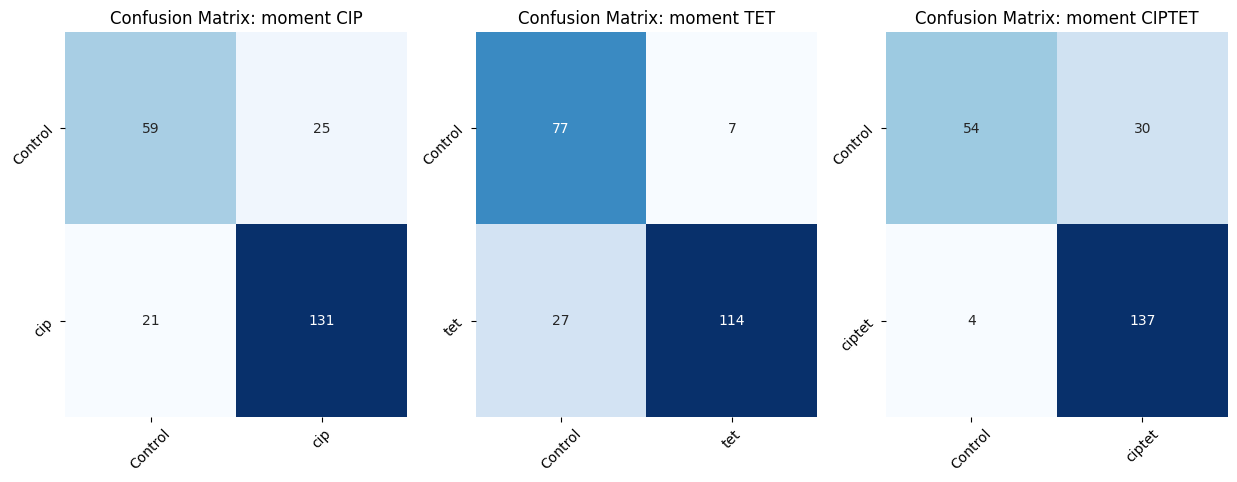

In [13]:
ename = 'moment'
tasks = ['cip', 'tet', 'ciptet']

fig, ax = plt.subplots(1, 3, figsize=(15,5))

for idx, task in enumerate(tasks):

    result_df = pd.read_csv(f'./results/predictions/final_test_predictions_tsclassifier_{ename}_{task}.csv')
    y_true = result_df['y_true'].to_list()
    y_pred = result_df['y_pred'].to_list()
    y_probs = result_df['y_probs'].to_list()

    confusion_matrix = sklearn.metrics.confusion_matrix(y_true, y_pred)
    # confusion_matrix = confusion_matrix/np.sum(confusion_matrix)*100
    b = sns.heatmap(
        confusion_matrix, 
        annot=True, 
        xticklabels=False, 
        yticklabels=False, 
        cbar=False, 
        cmap="Blues",
        fmt='g',
        ax=ax[idx]
    )
    b.set_title(f'Confusion Matrix: {ename} {task.upper()}')
    b.set_xticks([0.5,1.5],['Control',task],rotation=45)
    b.set_yticks([0.5,1.5],['Control',task],rotation=45)

    # Accurcy
    accuracy = accuracy_score(y_pred=y_pred, y_true=y_true)
    # AUROC
    auroc = roc_auc_score(y_true, y_probs)
    # AUPRC
    precision, recall, _ = precision_recall_curve(y_true, y_probs)
    auprc = auc(recall, precision)
    # Precision
    precision = precision_score(y_true, y_pred, zero_division=0)
    # Recall
    recall = recall_score(y_true, y_pred, zero_division=0)
    # f1
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(
        f"task: {task} \n"
        f"accuracy: {accuracy} \n"
        f"precision: {precision}  \n"
        f"recall: {recall}  \n"
        f"f1: {f1}  \n"
        f"auroc: {auroc}  \n"
        f"auprc: {auprc} \n"
    )